In [24]:
# === INSTALL (jeśli potrzeba) ===
# !pip install pandas numpy matplotlib seaborn requests tqdm

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from tqdm import tqdm

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# Electricity maps - Zone PL

Pobieram 2024-01-01 ...
Pobieram 2024-01-02 ...
Pobieram 2024-01-03 ...
Pobieram 2024-01-04 ...
Pobieram 2024-01-05 ...
Pobieram 2024-01-06 ...
Pobieram 2024-01-07 ...

✔ Pobrano 2009 rekordów

=== BASIC STATS ===
count    2009.000000
mean      771.764559
std        52.539056
min       635.000000
25%       742.000000
50%       774.000000
75%       802.000000
max       899.000000
Name: carbonIntensity, dtype: float64

=== MISSING VALUES ===
datetime              0
carbonIntensity       0
isEstimated           0
emissionFactorType    0
dtype: int64

=== ESTIMATIONS ===
isEstimated
False    2009
Name: count, dtype: int64


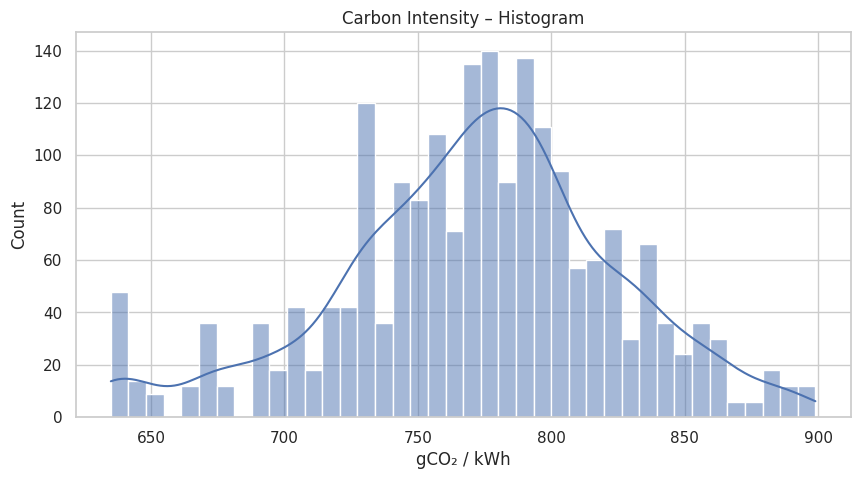

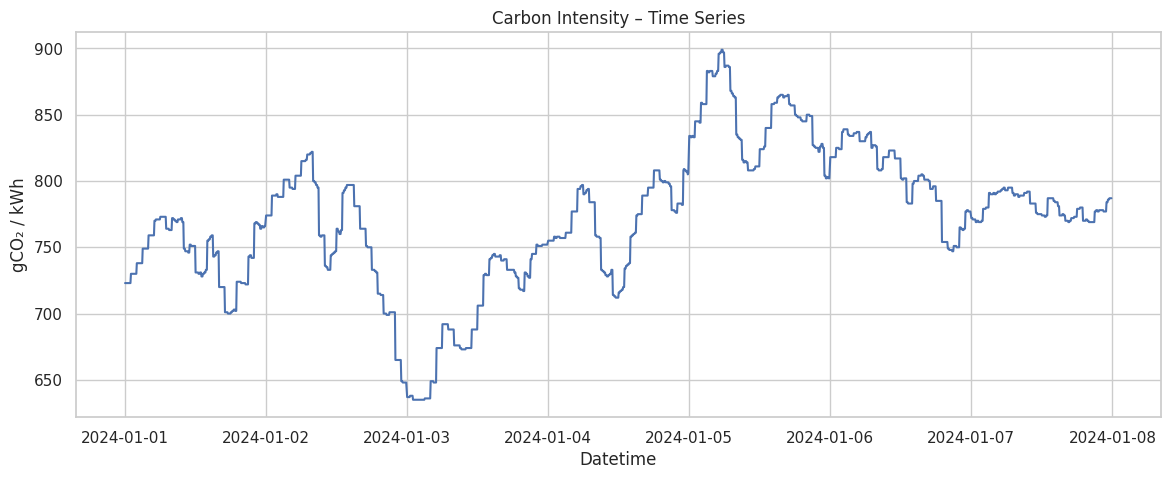

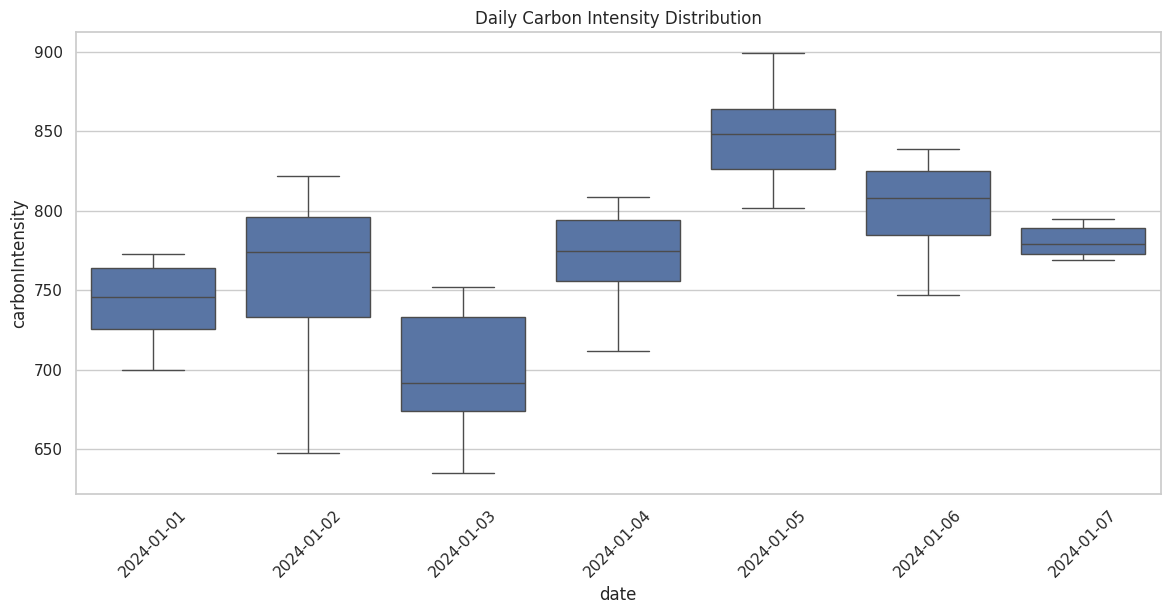

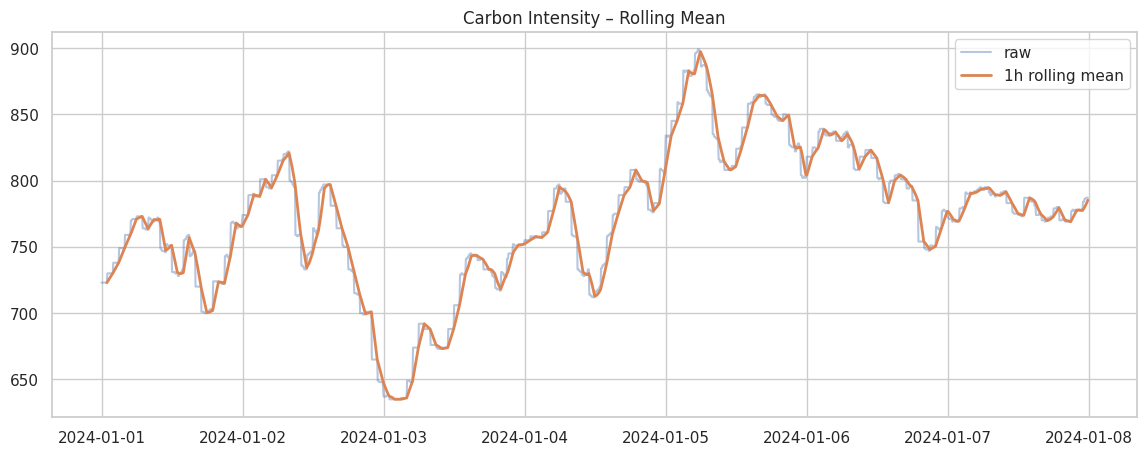

In [18]:
TOKEN = "kXJnlnuB1a4NG1mAqIrq"
# =============================
# 1. IMPORTY
# =============================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style="whitegrid")

# =============================
# 2. KONFIGURACJA
# =============================

BASE_URL = "https://api.electricitymaps.com/v3/carbon-intensity/past-range"

ZONE = "PL"
TEMPORAL = "5_minutes"

START_DATE = "2024-01-01"
END_DATE   = "2024-01-07"   # ← zmień zakres (np. tydzien)

HEADERS = {
    "auth-token": TOKEN
}

# =============================
# 3. FUNKCJA POBIERAJĄCA 1 DZIEŃ
# =============================
def fetch_one_day(date_str):
    start = f"{date_str}T00:00"
    end   = f"{date_str}T23:55"

    params = {
        "zone": ZONE,
        "temporalGranularity": TEMPORAL,
        "start": start,
        "end": end,
        "disableEstimations": "true"
    }

    r = requests.get(BASE_URL, params=params, headers=HEADERS)
    r.raise_for_status()

    data = r.json().get("data", [])
    return pd.DataFrame(data)

# =============================
# 4. POBIERANIE HISTORYCZNE (LOOP)
# =============================
dfs = []

current = datetime.fromisoformat(START_DATE)
end_dt  = datetime.fromisoformat(END_DATE)

while current <= end_dt:
    day = current.strftime("%Y-%m-%d")
    print(f"Pobieram {day} ...")

    try:
        df_day = fetch_one_day(day)
        dfs.append(df_day)
    except Exception as e:
        print(f"❌ Błąd dla {day}: {e}")

    current += timedelta(days=1)

df = pd.concat(dfs, ignore_index=True)

print(f"\n✔ Pobrano {len(df)} rekordów")

# =============================
# 5. CLEANING
# =============================
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

# tylko interesujące kolumny
df = df[
    ["datetime", "carbonIntensity", "isEstimated", "emissionFactorType"]
]

# =============================
# 6. EDA – STATYSTYKI
# =============================
print("\n=== BASIC STATS ===")
print(df["carbonIntensity"].describe())

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== ESTIMATIONS ===")
print(df["isEstimated"].value_counts())

# =============================
# 7. HISTOGRAM
# =============================
plt.figure(figsize=(10,5))
sns.histplot(df["carbonIntensity"], bins=40, kde=True)
plt.title("Carbon Intensity – Histogram")
plt.xlabel("gCO₂ / kWh")
plt.ylabel("Count")
plt.show()

# =============================
# 8. TIME SERIES
# =============================
plt.figure(figsize=(14,5))
plt.plot(df["datetime"], df["carbonIntensity"])
plt.title("Carbon Intensity – Time Series")
plt.xlabel("Datetime")
plt.ylabel("gCO₂ / kWh")
plt.show()

# =============================
# 9. BOXPLOT (DZIENNY)
# =============================
df["date"] = df["datetime"].dt.date

plt.figure(figsize=(14,6))
sns.boxplot(x="date", y="carbonIntensity", data=df)
plt.xticks(rotation=45)
plt.title("Daily Carbon Intensity Distribution")
plt.show()

# =============================
# 10. ROLLING MEAN
# =============================
df["rolling_1h"] = df["carbonIntensity"].rolling(12).mean()

plt.figure(figsize=(14,5))
plt.plot(df["datetime"], df["carbonIntensity"], alpha=0.4, label="raw")
plt.plot(df["datetime"], df["rolling_1h"], label="1h rolling mean", linewidth=2)
plt.legend()
plt.title("Carbon Intensity – Rolling Mean")
plt.show()


Weather data

CARBON INTENSITY


,carbonIntensity
count,288.000000
mean,743.916667
std,21.463363
min,700.000000
25%,727.000000
50%,746.500000
75%,764.000000
max,773.000000


RENEWABLE ENERGY (%)


,value
count,288.000000
mean,26.416667
std,1.954179
min,23.000000
25%,25.000000
50%,26.000000
75%,28.000000
max,30.000000


TOTAL LOAD (MW)


,value
count,288.000000
mean,14222.540937
std,1515.192084
min,12252.460000
25%,12686.747500
50%,14129.835000
75%,15675.765000
max,16341.730000


ELECTRICITY MIX (MW)


,nuclear,geothermal,biomass,coal,wind,solar,hydro,gas,oil,unknown,hydro discharge,battery discharge
count,288.0,288.0,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.0,288.000000,288.0
mean,0.0,0.0,274.291667,8299.500000,1859.041667,186.083333,306.250000,1873.333333,369.083333,0.0,75.291667,0.0
std,0.0,0.0,1.622469,379.698689,438.787415,304.766170,40.289458,153.370677,1.607907,0.0,86.863815,0.0
min,0.0,0.0,269.000000,7669.000000,1218.000000,0.000000,247.000000,1574.000000,366.000000,0.0,0.000000,0.0
25%,0.0,0.0,273.750000,7940.000000,1433.000000,0.000000,273.750000,1764.500000,368.000000,0.0,12.000000,0.0
50%,0.0,0.0,274.500000,8356.000000,1979.000000,0.000000,320.000000,1954.000000,369.500000,0.0,26.000000,0.0
75%,0.0,0.0,275.000000,8594.500000,2252.750000,263.750000,335.750000,1983.000000,370.000000,0.0,112.000000,0.0
max,0.0,0.0,277.000000,8919.000000,2486.000000,916.000000,362.000000,2005.000000,372.000000,0.0,262.000000,0.0


,carbonIntensity,renewable_pct,total_load_mw
datetime,,,
2024-01-01 00:00:00+00:00,723,30,13052.33
2024-01-01 00:05:00+00:00,723,30,13052.33
2024-01-01 00:10:00+00:00,723,30,13052.33
2024-01-01 00:15:00+00:00,723,30,13072.73
2024-01-01 00:20:00+00:00,723,30,13072.73


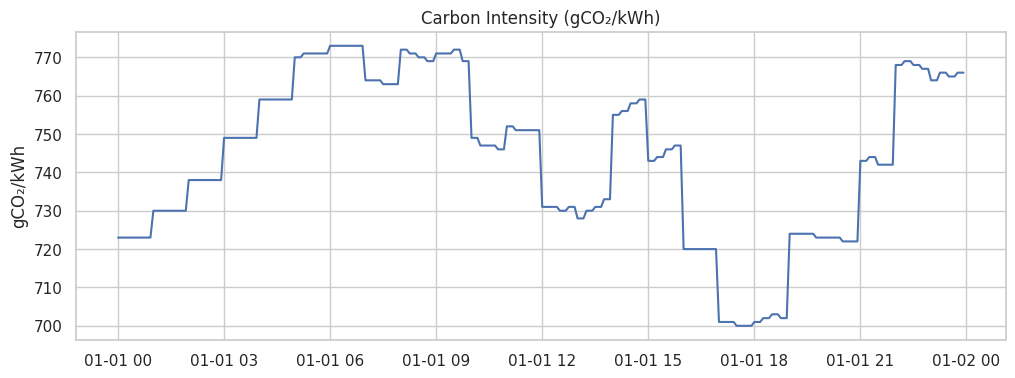

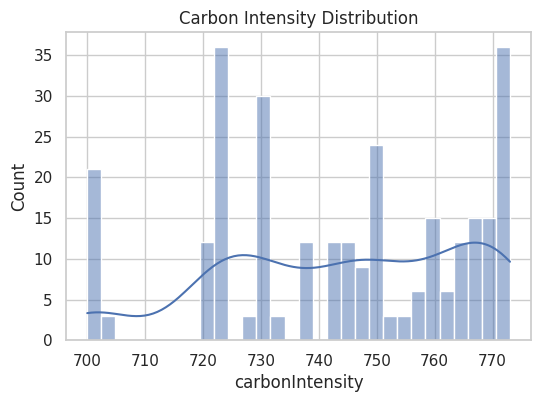

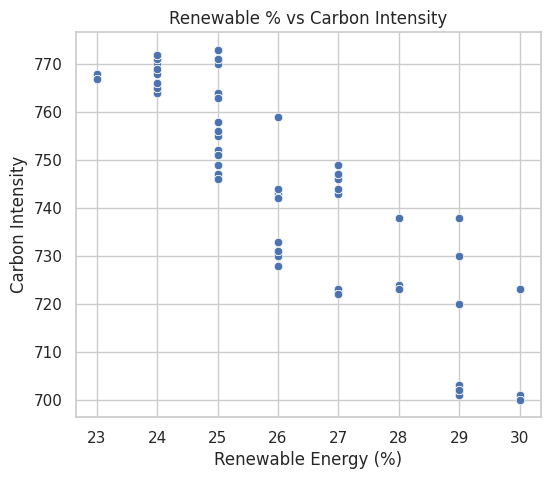

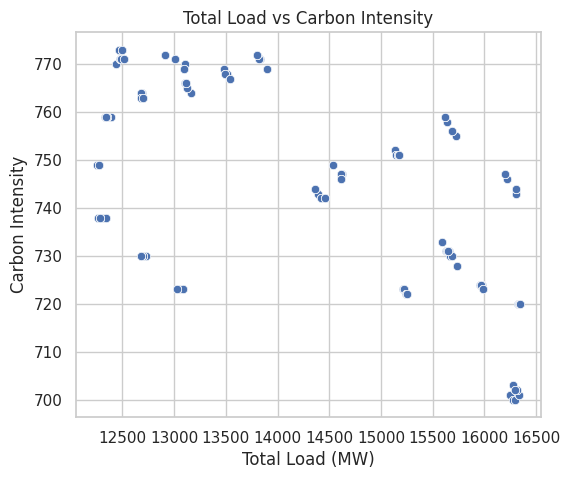

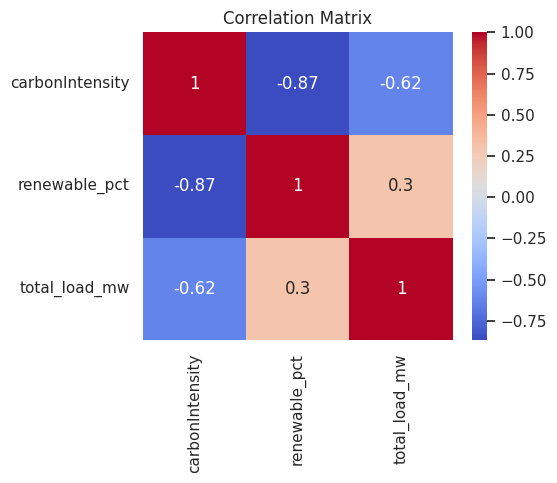

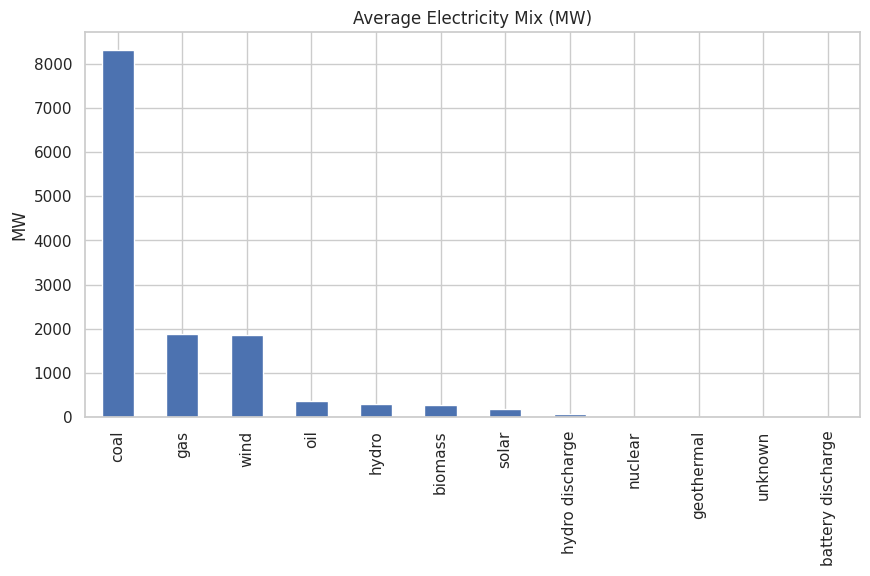

Final dataset shape: (288, 3)
Missing values:
carbonIntensity    0
renewable_pct      0
total_load_mw      0
dtype: int64


In [19]:
# ===============================
# CONFIG
# ===============================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TOKEN = "kXJnlnuB1a4NG1mAqIrq"
sns.set(style="whitegrid")

ZONE = "PL"

START = "2024-01-01T00:00"
END   = "2024-01-02T00:00"

HEADERS = {
    "auth-token": TOKEN
}

BASE_URL = "https://api.electricitymaps.com/v3"


# ===============================
# HELPER FUNCTION
# ===============================
def fetch_em(endpoint, extra_params=None):
    params = {
        "zone": ZONE,
        "temporalGranularity": "5_minutes",
        "start": START,
        "end": END,
        "disableEstimations": "true"
    }
    if extra_params:
        params.update(extra_params)

    r = requests.get(f"{BASE_URL}/{endpoint}", params=params, headers=HEADERS)
    r.raise_for_status()
    return r.json()["data"]


# ===============================
# 1. CARBON INTENSITY
# ===============================
carbon = fetch_em("carbon-intensity/past-range")

df_carbon = pd.DataFrame(carbon)
df_carbon["datetime"] = pd.to_datetime(df_carbon["datetime"])
df_carbon = df_carbon.set_index("datetime")

print("CARBON INTENSITY")
display(df_carbon["carbonIntensity"].describe())


# ===============================
# 2. RENEWABLE ENERGY (%)
# ===============================
renew = fetch_em("renewable-energy/past-range")

df_renew = pd.DataFrame(renew)
df_renew["datetime"] = pd.to_datetime(df_renew["datetime"])
df_renew = df_renew.set_index("datetime")

print("RENEWABLE ENERGY (%)")
display(df_renew["value"].describe())


# ===============================
# 3. TOTAL LOAD (MW)
# ===============================
load = fetch_em("total-load/past-range")

df_load = pd.DataFrame(load)
df_load["datetime"] = pd.to_datetime(df_load["datetime"])
df_load = df_load.set_index("datetime")

print("TOTAL LOAD (MW)")
display(df_load["value"].describe())


# ===============================
# 4. ELECTRICITY MIX (MW)
# ===============================
mix = fetch_em(
    "electricity-mix/past-range",
    extra_params={"flowTraced": "false"}
)

rows = []
for item in mix:
    dt = pd.to_datetime(item["datetime"])
    mix_dict = item["mix"] or {}
    mix_dict = {k: (v if v is not None else 0) for k, v in mix_dict.items()}
    mix_dict["datetime"] = dt
    rows.append(mix_dict)

df_mix = pd.DataFrame(rows).set_index("datetime")

print("ELECTRICITY MIX (MW)")
display(df_mix.describe())


# ===============================
# MERGE DATASETS
# ===============================
df = (
    df_carbon[["carbonIntensity"]]
    .join(df_renew[["value"]].rename(columns={"value": "renewable_pct"}))
    .join(df_load[["value"]].rename(columns={"value": "total_load_mw"}))
)

display(df.head())


# ===============================
# EDA – PLOTS
# ===============================

# --- Carbon Intensity Time Series ---
plt.figure(figsize=(12,4))
plt.plot(df.index, df["carbonIntensity"])
plt.title("Carbon Intensity (gCO₂/kWh)")
plt.ylabel("gCO₂/kWh")
plt.show()

# --- Histogram ---
plt.figure(figsize=(6,4))
sns.histplot(df["carbonIntensity"], bins=30, kde=True)
plt.title("Carbon Intensity Distribution")
plt.show()

# --- Renewable % vs Carbon ---
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["renewable_pct"],
    y=df["carbonIntensity"]
)
plt.title("Renewable % vs Carbon Intensity")
plt.xlabel("Renewable Energy (%)")
plt.ylabel("Carbon Intensity")
plt.show()

# --- Load vs Carbon ---
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["total_load_mw"],
    y=df["carbonIntensity"]
)
plt.title("Total Load vs Carbon Intensity")
plt.xlabel("Total Load (MW)")
plt.ylabel("Carbon Intensity")
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# ===============================
# ELECTRICITY MIX – STRUCTURE
# ===============================
mix_mean = df_mix.mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
mix_mean.plot(kind="bar")
plt.title("Average Electricity Mix (MW)")
plt.ylabel("MW")
plt.show()


# ===============================
# FINAL INFO
# ===============================
print("Final dataset shape:", df.shape)
print("Missing values:")
print(df.isna().sum())


Status: 200
       carbonIntensity
count       287.000000
mean        743.839721
std          21.461026
min         700.000000
25%         726.000000
50%         746.000000
75%         764.000000
max         773.000000

=== MISSING VALUES ===
zone                    0
carbonIntensity         0
updatedAt               0
createdAt               0
emissionFactorType      0
isEstimated             0
estimationMethod      287
dtype: int64


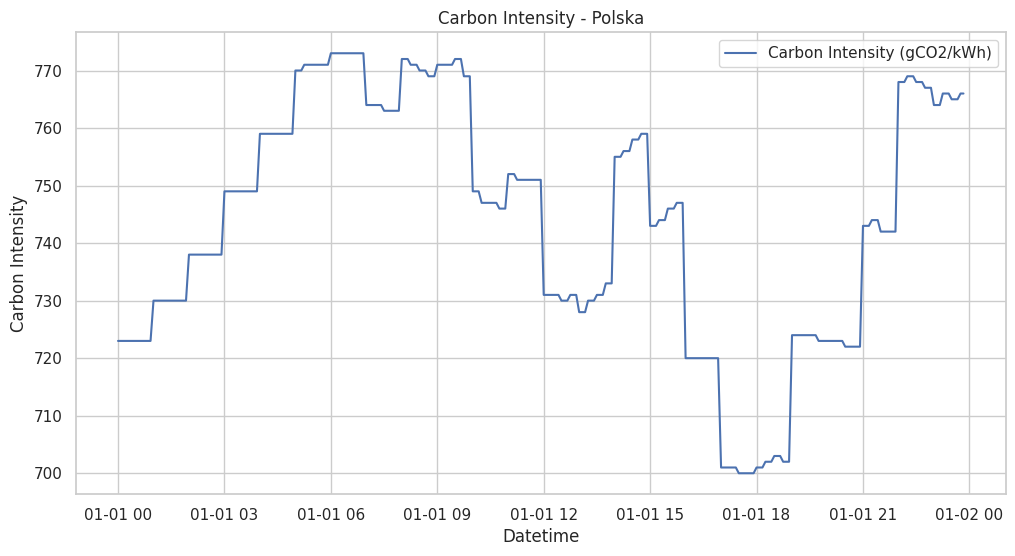

Status Open-Meteo: 200
       temperature_2m  relative_humidity_2m  precipitation  wind_speed_10m  \
count       48.000000             48.000000           48.0       48.000000   
mean         3.041667             82.875000            0.0        5.631250   
std          0.356002              5.719042            0.0        1.726164   
min          2.500000             76.000000            0.0        1.800000   
25%          2.800000             78.000000            0.0        4.300000   
50%          2.950000             80.500000            0.0        5.800000   
75%          3.325000             86.250000            0.0        6.575000   
max          3.800000             96.000000            0.0        9.000000   

       cloud_cover  
count         48.0  
mean         100.0  
std            0.0  
min          100.0  
25%          100.0  
50%          100.0  
75%          100.0  
max          100.0  


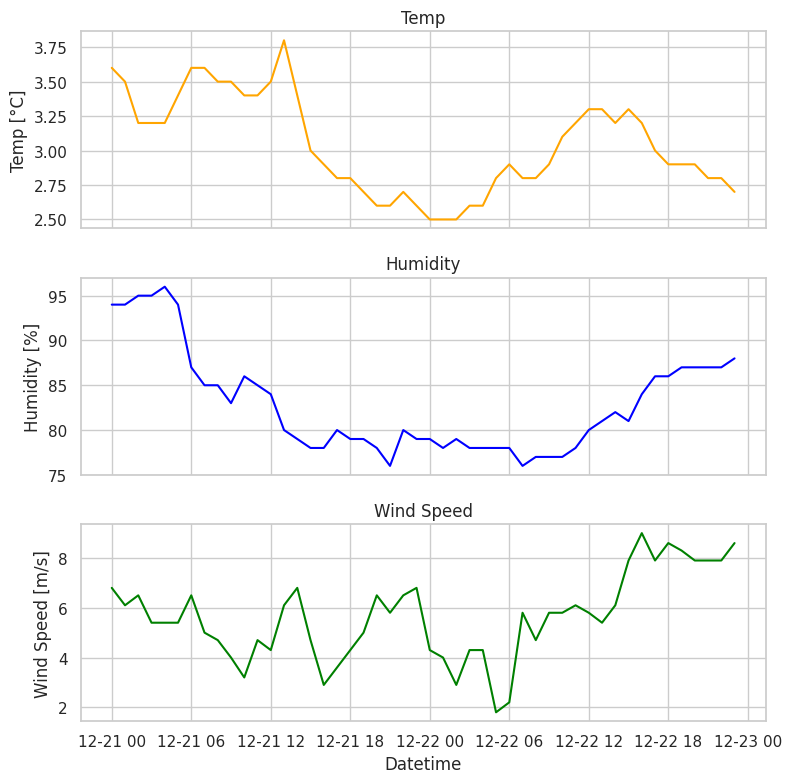

In [26]:

# -----------------------------
# IMPORTY
# -----------------------------
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set(style="whitegrid")

# -----------------------------
# PARAMETRY
# -----------------------------

# Historyczne dane carbon intensity (przykładowo 1 dzień)
start_date = "2024-01-01T00:00"
end_date   = "2024-01-01T23:55"

em_url = "https://api.electricitymaps.com/v3/carbon-intensity/past-range"
em_params = {
    "zone": "PL",
    "temporalGranularity": "5_minutes",
    "start": start_date,
    "end": end_date
}
em_headers = {"auth-token": TOKEN}

# -----------------------------
# POBIERANIE DANYCH CARBON
# -----------------------------
r = requests.get(em_url, params=em_params, headers=em_headers)
print(f"Status: {r.status_code}")

data_em = r.json()["data"]
df_em = pd.DataFrame(data_em)
df_em['datetime'] = pd.to_datetime(df_em['datetime'])
df_em.set_index('datetime', inplace=True)

print(df_em.describe())
print("\n=== MISSING VALUES ===")
print(df_em.isna().sum())

# -----------------------------
# WYKRES CARBON INTENSITY
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_em.index, df_em['carbonIntensity'], label='Carbon Intensity (gCO2/kWh)')
plt.xlabel("Datetime")
plt.ylabel("Carbon Intensity")
plt.title("Carbon Intensity - Polska")
plt.legend()
plt.show()

# -----------------------------
# DANE METEO Z OPEN-METEO
# -----------------------------
latitude = 52.2298
longitude = 21.0118

om_url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&past_days=1&forecast_days=1&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,cloud_cover"

r_om = requests.get(om_url)
print(f"Status Open-Meteo: {r_om.status_code}")

data_om = r_om.json()['hourly']
df_om = pd.DataFrame(data_om)
df_om['time'] = pd.to_datetime(df_om['time'])
df_om.set_index('time', inplace=True)

print(df_om.describe())

# -----------------------------
# WYKRES METEO
# -----------------------------
fig, axs = plt.subplots(3,1, figsize=(8,8), sharex=True)

# Temperatura
axs[0].plot(df_om.index, df_om['temperature_2m'], color='orange')
axs[0].set_ylabel("Temp [°C]")
axs[0].set_title("Temp")

# Wilgotność
axs[1].plot(df_om.index, df_om['relative_humidity_2m'], color='blue')
axs[1].set_ylabel("Humidity [%]")
axs[1].set_title("Humidity")

# Prędkość wiatru
axs[2].plot(df_om.index, df_om['wind_speed_10m'], color='green')
axs[2].set_ylabel("Wind Speed [m/s]")
axs[2].set_title("Wind Speed")
axs[2].set_xlabel("Datetime")

plt.tight_layout()
plt.show()



# Merge

In [32]:
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone
import json

TOKEN = "kXJnlnuB1a4NG1mAqIrq"
em_url = "https://api.electricitymaps.com/v3/electricity-mix/past-range"

# Zakres dat tygodnia
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=7)

all_days = []
current_day = start_date

while current_day < end_date:
    next_day = current_day + timedelta(days=1)
    params = {
        "zone": "PL",
        "temporalGranularity": "5_minutes",
        "start": current_day.strftime("%Y-%m-%dT%H:%M"),
        "end": next_day.strftime("%Y-%m-%dT%H:%M"),
        "flowTraced": "false"
    }
    r = requests.get(em_url, params=params, headers={"auth-token": TOKEN})
    print(current_day.strftime("%Y-%m-%d"), r.status_code)
    try:
        response_json = r.json()
        if "data" in response_json:
            all_days.extend(response_json["data"])
        else:
            print("Brak danych dla dnia:", current_day.strftime("%Y-%m-%d"))
    except Exception as e:
        print("Błąd parsowania JSON:", e)
    current_day = next_day

# Tworzymy DataFrame
mix_list = []
for row in all_days:
    dt = row['datetime']
    mix = row['mix']
    mix['datetime'] = dt
    mix_list.append(mix)

df_em = pd.DataFrame(mix_list)
df_em['datetime'] = pd.to_datetime(df_em['datetime'])
df_em.set_index('datetime', inplace=True)
df_em.fillna(0, inplace=True)
print(df_em.head())


2025-12-15 200
2025-12-16 200
2025-12-17 200
2025-12-18 200
2025-12-19 200
2025-12-20 200
2025-12-21 200
                           nuclear  geothermal  biomass   coal  wind  solar  \
datetime                                                                      
2025-12-15 13:30:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:35:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:40:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:45:00+00:00        0           0      190  14003  1637    789   
2025-12-15 13:50:00+00:00        0           0      190  14003  1637    789   

                           hydro   gas  oil  unknown  hydro discharge  \
datetime                                                                
2025-12-15 13:30:00+00:00    198  4330  194      707              415   
2025-12-15 13:35:00+00:00    198  4330  194      707              415   
2025-12-15 13:40:00+00:00    198  4330  194      

/tmp/ipython-input-860329905.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_em.fillna(0, inplace=True)


                           nuclear  geothermal  biomass   coal  wind  solar  \
2025-12-15 13:30:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:35:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:40:00+00:00        0           0      187  14001  1615   1171   
2025-12-15 13:45:00+00:00        0           0      190  14003  1637    789   
2025-12-15 13:50:00+00:00        0           0      190  14003  1637    789   

                           hydro   gas  oil  unknown  hydro discharge  \
2025-12-15 13:30:00+00:00    198  4330  194      707              415   
2025-12-15 13:35:00+00:00    198  4330  194      707              415   
2025-12-15 13:40:00+00:00    198  4330  194      707              415   
2025-12-15 13:45:00+00:00    229  4375  194      705              652   
2025-12-15 13:50:00+00:00    229  4375  194      705              652   

                           battery discharge  temperature_2m  wind_speed_10m  \
2025-1

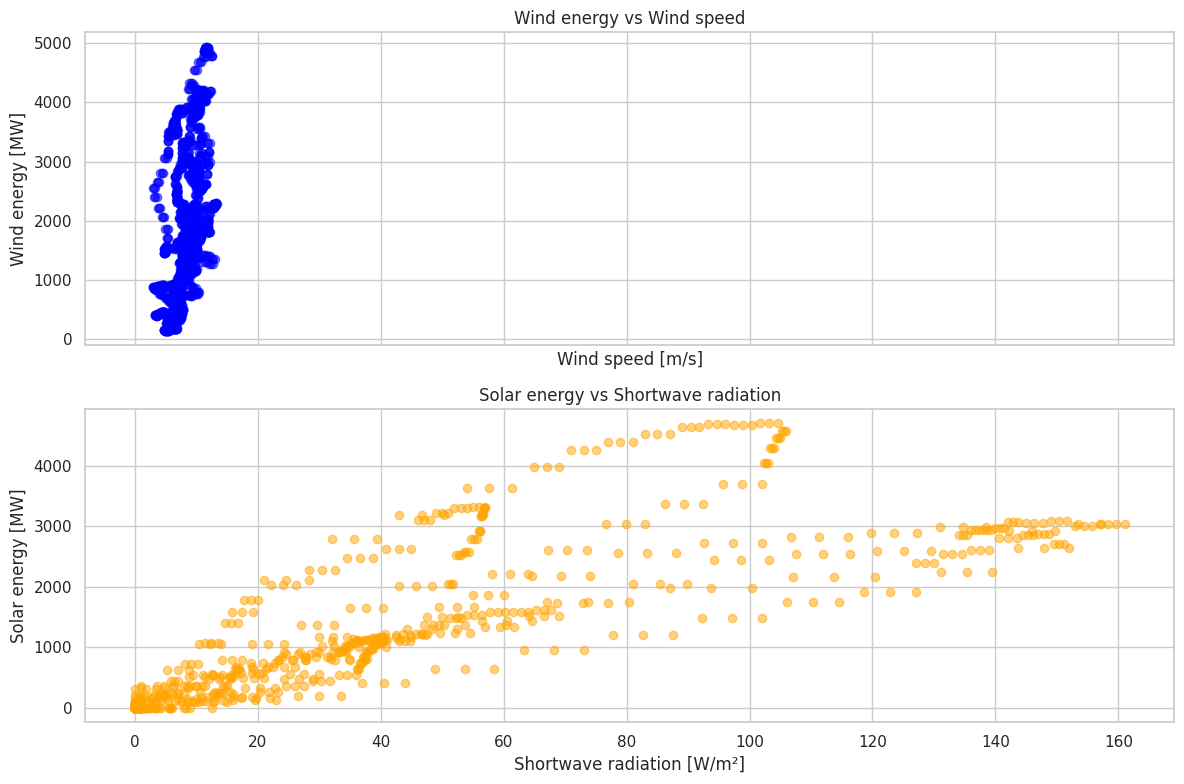

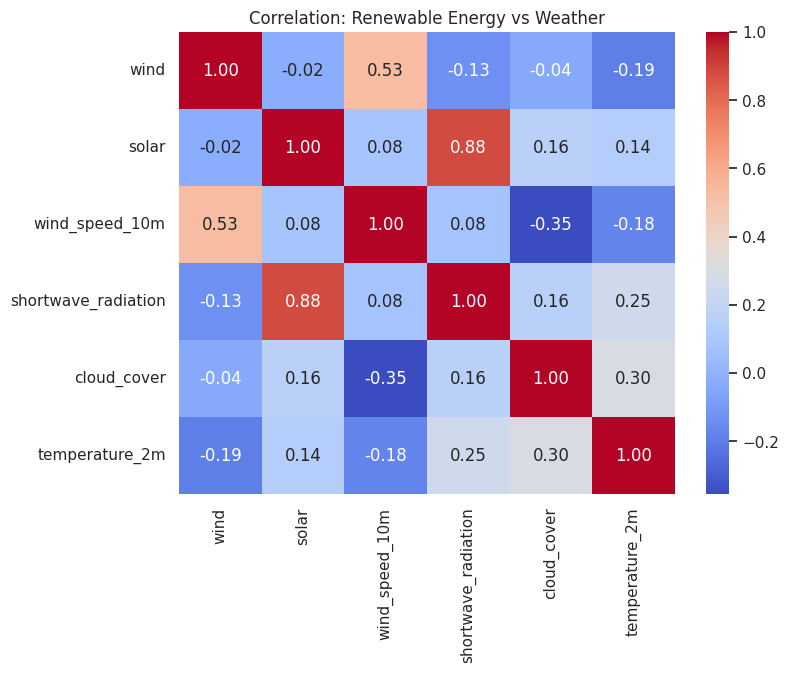

In [34]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone

sns.set(style="whitegrid")

# -----------------------------
# Open-Meteo
# -----------------------------
latitude = 52.2298
longitude = 21.0118
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=7)

start_str = start_date.strftime("%Y-%m-%d")
end_str   = end_date.strftime("%Y-%m-%d")

om_url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={latitude}&longitude={longitude}&past_days=7&forecast_days=0&hourly="
    "temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover"
)

r_om = requests.get(om_url)
data_om = r_om.json()['hourly']

# DataFrame
df_om = pd.DataFrame(data_om)
df_om['time'] = pd.to_datetime(df_om['time'])
df_om.set_index('time', inplace=True)

# Resampling  5-min (interpolation)
df_om_5min = df_om.resample('5min').interpolate()
df_om_5min.index = df_om_5min.index.tz_localize('UTC')
df_em.index = df_em.index.tz_convert('UTC')

df_merged = df_em.join(df_om_5min, how='inner')
print(df_merged.head())


# -----------------------------
#  Wind/Solar vs weather
# -----------------------------
fig, axs = plt.subplots(2,1, figsize=(12,8), sharex=True)

# Wind energy vs wind speed
axs[0].scatter(df_merged['wind_speed_10m'], df_merged['wind'], alpha=0.5, color='blue')
axs[0].set_xlabel("Wind speed [m/s]")
axs[0].set_ylabel("Wind energy [MW]")
axs[0].set_title("Wind energy vs Wind speed")

# Solar energy vs shortwave radiation
axs[1].scatter(df_merged['shortwave_radiation'], df_merged['solar'], alpha=0.5, color='orange')
axs[1].set_xlabel("Shortwave radiation [W/m²]")
axs[1].set_ylabel("Solar energy [MW]")
axs[1].set_title("Solar energy vs Shortwave radiation")

plt.tight_layout()
plt.show()

# -----------------------------
# Corelation
# -----------------------------
features = ['wind', 'solar']
weather = ['wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'temperature_2m']

corr_matrix = df_merged[features + weather].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Renewable Energy vs Weather")
plt.show()
